**Import Libraries**

In [7]:
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np
import random
import os
import time

**Hyperparameter**

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR-10 images are 3x32x32 (RGB)
IMAGE_SIZE   = 32
CHANNELS     = 3          # RGB is 3  for CIFAR10
Z_DIM        = 100        # latent noise vector size
HIDDEN_DIM   = 64
BATCH_SIZE   = 128
LR           = 0.0002
BETA1        = 0.5        # Adam momentum
NUM_EPOCHS   = 50

print(f"Training on: {device}")

Training on: cuda


### Load CIFAR-10 Dataset

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),   # 3 channels
        std=(0.5, 0.5, 0.5)     # normalize to [-1, 1]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)



### Labels

In [10]:
CLASSES = ('plane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck')

print(f"Dataset size: {len(train_dataset)}")

Dataset size: 50000


### Visualize Sample CIFAR-10 Images

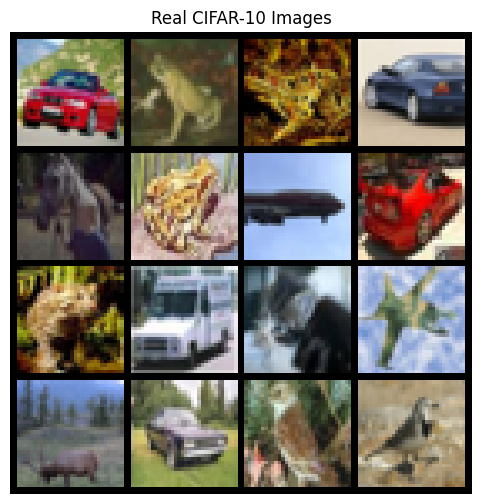

Image shape: torch.Size([128, 3, 32, 32])


In [11]:
def show_images(images, title=""):
    images = images * 0.5 + 0.5   # denormalize back to [0,1]
    grid = make_grid(images[:16], nrow=4)
    npimg = grid.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(npimg)
    plt.title(title)
    plt.axis('off')
    plt.show()

real_batch, labels = next(iter(train_loader))
show_images(real_batch, title="Real CIFAR-10 Images")
print("Image shape:", real_batch.shape)

###  Generator Network

In [12]:
class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, channels):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Input: z_dim x 1 x 1
            self._block(z_dim, hidden_dim * 8, 4, 1, 0),     # → 512 x 4 x 4
            self._block(hidden_dim * 8, hidden_dim * 4, 4, 2, 1),  # → 256 x 8 x 8
            self._block(hidden_dim * 4, hidden_dim * 2, 4, 2, 1),  # → 128 x 16 x 16
            # Final layer: no BatchNorm, use Tanh
            nn.ConvTranspose2d(hidden_dim * 2, channels, 4, 2, 1), # → 3 x 32 x 32
            nn.Tanh()
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, z):
        # z shape: [batch, z_dim, 1, 1]
        return self.model(z)


In [13]:
# Test Generator
gen = Generator(Z_DIM, HIDDEN_DIM, CHANNELS).to(device)
noise = torch.randn(4, Z_DIM, 1, 1).to(device)
fake = gen(noise)
print("Generator output shape:", fake.shape)  # [4, 3, 32, 32]

Generator output shape: torch.Size([4, 3, 32, 32])


###  Discriminator Network

In [14]:
class Discriminator(nn.Module):
    def __init__(self, channels, hidden_dim):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # Input: 3 x 32 x 32
            self._block(channels, hidden_dim, 4, 2, 1, bn=False),     # → 64 x 16 x 16
            self._block(hidden_dim, hidden_dim * 2, 4, 2, 1),         # → 128 x 8 x 8
            self._block(hidden_dim * 2, hidden_dim * 4, 4, 2, 1),     # → 256 x 4 x 4
            # Final: 4x4 → 1x1
            nn.Conv2d(hidden_dim * 4, 1, 4, 1, 0),                    # → 1 x 1 x 1
            nn.Sigmoid()
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding, bn=True):
        layers = [nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False)]
        if bn:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x).view(-1)  # flatten to [batch]


In [15]:
# Test Discriminator
disc = Discriminator(CHANNELS, HIDDEN_DIM).to(device)
out = disc(fake)
print("Discriminator output shape:", out.shape)  # [4]

Discriminator output shape: torch.Size([4])


###  Weights Initialization

In [16]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

gen.apply(weights_init)
disc.apply(weights_init)
print("Weights initialized!")

Weights initialized!


### Loss & Optimizers

In [17]:
criterion = nn.BCELoss()

opt_gen  = optim.Adam(gen.parameters(),  lr=LR, betas=(BETA1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise for visualization consistency across epochs
fixed_noise = torch.randn(16, Z_DIM, 1, 1).to(device)

print("Optimizers ready!")

Optimizers ready!


###  Training Loop

Epoch [01/50] | Loss_D: 0.3296 | Loss_G: 3.7871
Epoch [02/50] | Loss_D: 0.2967 | Loss_G: 3.4162
Epoch [03/50] | Loss_D: 0.3282 | Loss_G: 2.9932
Epoch [04/50] | Loss_D: 0.2983 | Loss_G: 2.8573
Epoch [05/50] | Loss_D: 0.3365 | Loss_G: 2.6385
Epoch [06/50] | Loss_D: 0.3858 | Loss_G: 2.3061
Epoch [07/50] | Loss_D: 0.4332 | Loss_G: 2.2406
Epoch [08/50] | Loss_D: 0.4335 | Loss_G: 2.1009
Epoch [09/50] | Loss_D: 0.4333 | Loss_G: 2.0141
Epoch [10/50] | Loss_D: 0.4430 | Loss_G: 1.9954


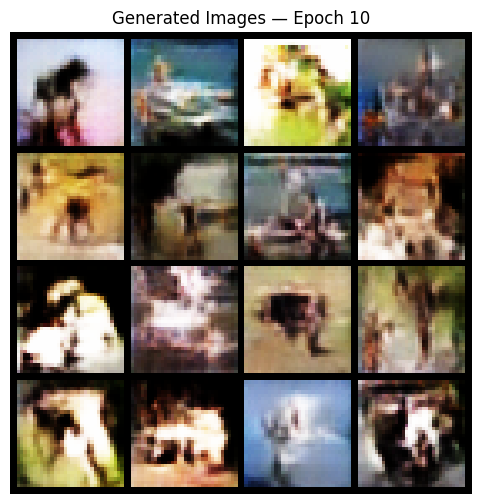

Epoch [11/50] | Loss_D: 0.4324 | Loss_G: 1.9118
Epoch [12/50] | Loss_D: 0.4324 | Loss_G: 1.8728
Epoch [13/50] | Loss_D: 0.4332 | Loss_G: 1.8883
Epoch [14/50] | Loss_D: 0.4559 | Loss_G: 1.8236
Epoch [15/50] | Loss_D: 0.4453 | Loss_G: 1.7976
Epoch [16/50] | Loss_D: 0.4582 | Loss_G: 1.7722
Epoch [17/50] | Loss_D: 0.4713 | Loss_G: 1.7749
Epoch [18/50] | Loss_D: 0.4575 | Loss_G: 1.7318
Epoch [19/50] | Loss_D: 0.4651 | Loss_G: 1.7183
Epoch [20/50] | Loss_D: 0.4657 | Loss_G: 1.7171


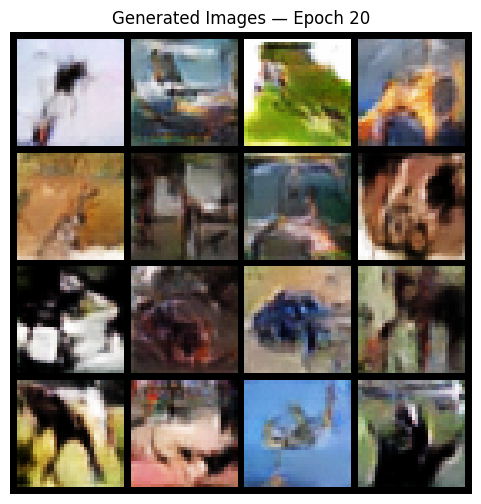

Epoch [21/50] | Loss_D: 0.4668 | Loss_G: 1.7103
Epoch [22/50] | Loss_D: 0.4645 | Loss_G: 1.7144
Epoch [23/50] | Loss_D: 0.4729 | Loss_G: 1.7198
Epoch [24/50] | Loss_D: 0.4684 | Loss_G: 1.7225
Epoch [25/50] | Loss_D: 0.4502 | Loss_G: 1.7156
Epoch [26/50] | Loss_D: 0.4877 | Loss_G: 1.7181
Epoch [27/50] | Loss_D: 0.4455 | Loss_G: 1.7157
Epoch [28/50] | Loss_D: 0.4679 | Loss_G: 1.7249
Epoch [29/50] | Loss_D: 0.4403 | Loss_G: 1.7539
Epoch [30/50] | Loss_D: 0.4508 | Loss_G: 1.7760


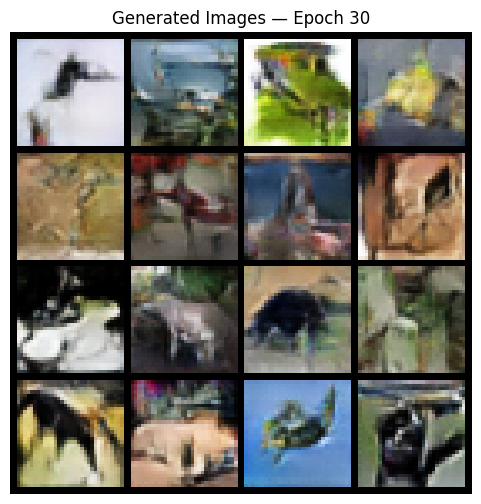

Epoch [31/50] | Loss_D: 0.4543 | Loss_G: 1.7595
Epoch [32/50] | Loss_D: 0.4343 | Loss_G: 1.7944
Epoch [33/50] | Loss_D: 0.4386 | Loss_G: 1.8352
Epoch [34/50] | Loss_D: 0.4268 | Loss_G: 1.7994
Epoch [35/50] | Loss_D: 0.4386 | Loss_G: 1.8343
Epoch [36/50] | Loss_D: 0.4087 | Loss_G: 1.8689
Epoch [37/50] | Loss_D: 0.4118 | Loss_G: 1.8899
Epoch [38/50] | Loss_D: 0.4678 | Loss_G: 1.8388
Epoch [39/50] | Loss_D: 0.4051 | Loss_G: 1.9124
Epoch [40/50] | Loss_D: 0.4129 | Loss_G: 1.9203


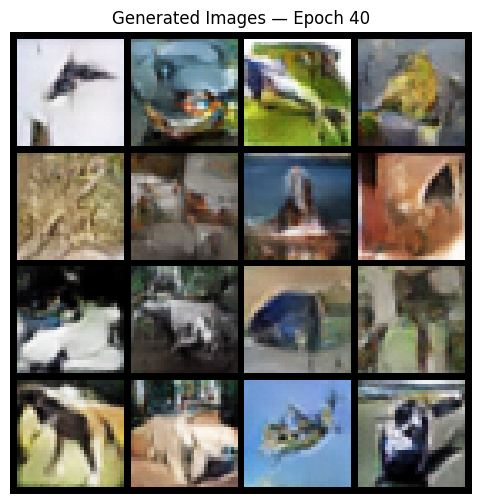

Epoch [41/50] | Loss_D: 0.3895 | Loss_G: 1.9443
Epoch [42/50] | Loss_D: 0.4152 | Loss_G: 1.9627
Epoch [43/50] | Loss_D: 0.3898 | Loss_G: 1.9763
Epoch [44/50] | Loss_D: 0.4060 | Loss_G: 2.0082
Epoch [45/50] | Loss_D: 0.3814 | Loss_G: 1.9899
Epoch [46/50] | Loss_D: 0.3866 | Loss_G: 2.0290
Epoch [47/50] | Loss_D: 0.4138 | Loss_G: 2.0120
Epoch [48/50] | Loss_D: 0.3802 | Loss_G: 2.0594
Epoch [49/50] | Loss_D: 0.3566 | Loss_G: 2.0739
Epoch [50/50] | Loss_D: 0.3634 | Loss_G: 2.1258


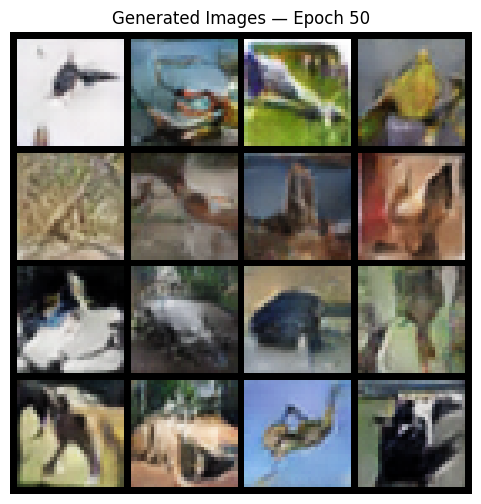


 Training complete!


In [18]:
G_losses = []
D_losses = []

gen.train()
disc.train()

for epoch in range(NUM_EPOCHS):
    epoch_g_loss = 0
    epoch_d_loss = 0

    for batch_idx, (real, _) in enumerate(train_loader):
        real = real.to(device)
        batch_size = real.size(0)

        # ─── Train Discriminator ───────────────────────────
        opt_disc.zero_grad()

        # Real images → label 1
        real_labels = torch.ones(batch_size).to(device)
        real_preds  = disc(real)
        loss_real   = criterion(real_preds, real_labels)

        # Fake images → label 0
        noise       = torch.randn(batch_size, Z_DIM, 1, 1).to(device)
        fake        = gen(noise)
        fake_labels = torch.zeros(batch_size).to(device)
        fake_preds  = disc(fake.detach())   # detach so G is not updated
        loss_fake   = criterion(fake_preds, fake_labels)

        loss_D = (loss_real + loss_fake) / 2
        loss_D.backward()
        opt_disc.step()

        # ─── Train Generator ───────────────────────────────
        opt_gen.zero_grad()

        # Generator wants disc to think fakes are real → label 1
        output   = disc(fake)
        loss_G   = criterion(output, real_labels)
        loss_G.backward()
        opt_gen.step()

        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()

    # Average losses
    avg_g = epoch_g_loss / len(train_loader)
    avg_d = epoch_d_loss / len(train_loader)
    G_losses.append(avg_g)
    D_losses.append(avg_d)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
          f"Loss_D: {avg_d:.4f} | Loss_G: {avg_g:.4f}")

    # Visualize every 10 epochs
    if (epoch + 1) % 10 == 0:
        gen.eval()
        with torch.no_grad():
            fake_imgs = gen(fixed_noise)
        show_images(fake_imgs, title=f"Generated Images — Epoch {epoch+1}")
        gen.train()

print("\n Training complete!")

###  Plot Training Losses

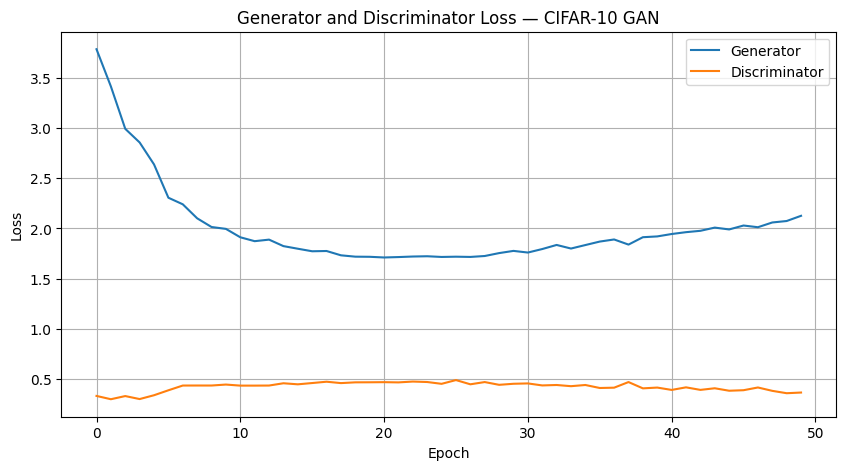

In [19]:
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss — CIFAR-10 GAN")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

###  Final Generated Images

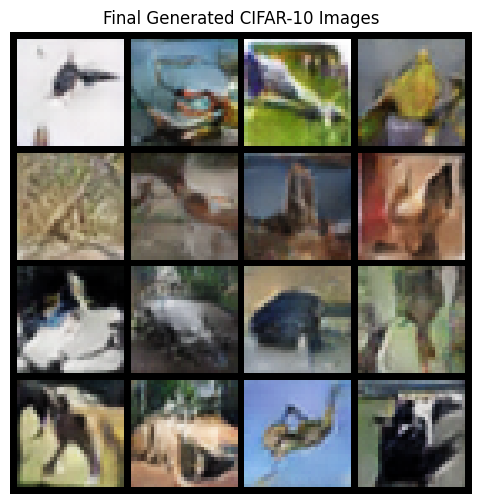

In [20]:
gen.eval()
with torch.no_grad():
    final_fake = gen(fixed_noise)

show_images(final_fake, title="Final Generated CIFAR-10 Images")

### Save Models

In [21]:
torch.save(gen.state_dict(),  "cifar10_generator.pth")
torch.save(disc.state_dict(), "cifar10_discriminator.pth")
print("Models saved!")

Models saved!
